In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Define data path
DATA_PATH = "../data/raw/"

# Load required tables
student_info = pd.read_csv(DATA_PATH + "studentInfo.csv")
student_vle = pd.read_csv(DATA_PATH + "studentVle.csv")
student_assessment = pd.read_csv(DATA_PATH + "studentAssessment.csv")
assessments = pd.read_csv(DATA_PATH + "assessments.csv")
vle = pd.read_csv(DATA_PATH + "vle.csv")

# Create at-risk labels
student_info['at_risk'] = (
    student_info['final_result'] == 'Withdrawn'
).astype(int)

print("Data loaded successfully!")
print(f"Students: {len(student_info):,}")
print(f"VLE interactions: {len(student_vle):,}")

Data loaded successfully!
Students: 32,593
VLE interactions: 10,655,280


In [3]:
# Merge studentVle with vle to get activity types
print("Merging VLE data with activity types...")

student_vle_merged = student_vle.merge(
    vle[['id_site', 'activity_type']],
    on='id_site',
    how='left'
)

# Convert date to week number
# OULAD dates are in days, convert to weeks
student_vle_merged['week'] = (
    student_vle_merged['date'] // 7
).clip(lower=0)

print(f"Merged shape: {student_vle_merged.shape}")
print(f"\nWeek range: {student_vle_merged['week'].min()} to {student_vle_merged['week'].max()}")
print(f"\nActivity types: {student_vle_merged['activity_type'].nunique()}")
print(f"\nSample:")
print(student_vle_merged[['id_student', 'week', 'activity_type', 'sum_click']].head())

Merging VLE data with activity types...
Merged shape: (10655280, 8)

Week range: 0 to 38

Activity types: 20

Sample:
   id_student  week activity_type  sum_click
0       28400     0       forumng          4
1       28400     0       forumng          1
2       28400     0       forumng          1
3       28400     0      homepage         11
4       28400     0     oucontent          1


In [4]:
# Extract 10 behavioral features per student per week
print("Extracting weekly behavioral features...")
print("This may take a few minutes...")

# Feature 1,2,7: clicks, active days, content diversity
weekly_clicks = student_vle_merged.groupby(
    ['id_student', 'code_module', 'code_presentation', 'week']
).agg(
    weekly_total_clicks=('sum_click', 'sum'),
    active_days=('date', 'nunique'),
    content_diversity=('activity_type', 'nunique')
).reset_index()

# Feature 3: forum posts
forum = student_vle_merged[
    student_vle_merged['activity_type'] == 'forumng'
].groupby(
    ['id_student', 'code_module', 'code_presentation', 'week']
).agg(
    forum_posts=('sum_click', 'sum')
).reset_index()

# Feature 4: forum replies (oucollaborate)
forum_replies = student_vle_merged[
    student_vle_merged['activity_type'] == 'oucollaborate'
].groupby(
    ['id_student', 'code_module', 'code_presentation', 'week']
).agg(
    forum_replies=('sum_click', 'sum')
).reset_index()

# Feature 5: quiz attempts
quiz = student_vle_merged[
    student_vle_merged['activity_type'] == 'quiz'
].groupby(
    ['id_student', 'code_module', 'code_presentation', 'week']
).agg(
    quiz_attempts=('sum_click', 'sum')
).reset_index()

# Feature 6: resource views
resource = student_vle_merged[
    student_vle_merged['activity_type'] == 'resource'
].groupby(
    ['id_student', 'code_module', 'code_presentation', 'week']
).agg(
    resource_views=('sum_click', 'sum')
).reset_index()

# Feature 9: night activity (proxy using oucontent late)
night = student_vle_merged[
    student_vle_merged['activity_type'] == 'oucontent'
].groupby(
    ['id_student', 'code_module', 'code_presentation', 'week']
).agg(
    night_activity=('sum_click', 'sum')
).reset_index()

print("Weekly aggregations done!")
print(f"Base weekly records: {len(weekly_clicks):,}")

Extracting weekly behavioral features...
This may take a few minutes...
Weekly aggregations done!
Base weekly records: 582,772


In [5]:
# Merge all features into one dataframe
print("Merging all features...")

# Start with base
features = weekly_clicks.copy()

# Merge forum posts
features = features.merge(
    forum, 
    on=['id_student', 'code_module', 'code_presentation', 'week'],
    how='left'
)

# Merge forum replies
features = features.merge(
    forum_replies,
    on=['id_student', 'code_module', 'code_presentation', 'week'],
    how='left'
)

# Merge quiz attempts
features = features.merge(
    quiz,
    on=['id_student', 'code_module', 'code_presentation', 'week'],
    how='left'
)

# Merge resource views
features = features.merge(
    resource,
    on=['id_student', 'code_module', 'code_presentation', 'week'],
    how='left'
)

# Merge night activity
features = features.merge(
    night,
    on=['id_student', 'code_module', 'code_presentation', 'week'],
    how='left'
)

# Fill missing with 0
features = features.fillna(0)

# Add at_risk label
features = features.merge(
    student_info[['id_student', 'code_module', 
                  'code_presentation', 'at_risk']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

print(f"Features shape: {features.shape}")
print(f"\nColumns: {list(features.columns)}")
print(f"\nSample:")
print(features.head())

Merging all features...
Features shape: (582772, 13)

Columns: ['id_student', 'code_module', 'code_presentation', 'week', 'weekly_total_clicks', 'active_days', 'content_diversity', 'forum_posts', 'forum_replies', 'quiz_attempts', 'resource_views', 'night_activity', 'at_risk']

Sample:
   id_student code_module code_presentation  week  weekly_total_clicks  \
0        6516         AAA             2014J     0                  485   
1        6516         AAA             2014J     1                   42   
2        6516         AAA             2014J     2                   79   
3        6516         AAA             2014J     3                  193   
4        6516         AAA             2014J     4                   69   

   active_days  content_diversity  forum_posts  forum_replies  quiz_attempts  \
0           15                  6        124.0            0.0            0.0   
1            4                  4         22.0            0.0            0.0   
2            5               

In [6]:
# Add days_since_last_login and inactive_weeks_count
print("Adding remaining features...")

# Sort by student and week
features = features.sort_values(
    ['id_student', 'code_module', 'code_presentation', 'week']
).reset_index(drop=True)

# Feature 8: days_since_last_login
# (difference between current week and previous active week)
features['days_since_login'] = features.groupby(
    ['id_student', 'code_module', 'code_presentation']
)['week'].diff().fillna(0)

# Feature 10: inactive_weeks_count
# (cumulative count of weeks with zero clicks)
features['inactive_week'] = (
    features['weekly_total_clicks'] == 0
).astype(int)

features['inactive_weeks_count'] = features.groupby(
    ['id_student', 'code_module', 'code_presentation']
)['inactive_week'].cumsum()

# Drop helper column
features = features.drop('inactive_week', axis=1)

print(f"Final features shape: {features.shape}")
print(f"\nAll columns: {list(features.columns)}")
print(f"\nMissing values:")
print(features.isnull().sum())

Adding remaining features...
Final features shape: (582772, 15)

All columns: ['id_student', 'code_module', 'code_presentation', 'week', 'weekly_total_clicks', 'active_days', 'content_diversity', 'forum_posts', 'forum_replies', 'quiz_attempts', 'resource_views', 'night_activity', 'at_risk', 'days_since_login', 'inactive_weeks_count']

Missing values:
id_student              0
code_module             0
code_presentation       0
week                    0
weekly_total_clicks     0
active_days             0
content_diversity       0
forum_posts             0
forum_replies           0
quiz_attempts           0
resource_views          0
night_activity          0
at_risk                 0
days_since_login        0
inactive_weeks_count    0
dtype: int64


In [7]:
# Filter to first 17 weeks only (like leader uses 17 weeks)
print("Filtering to first 17 weeks...")

features_17 = features[features['week'] < 17].copy()

print(f"Shape after filtering: {features_17.shape}")
print(f"Week range: {features_17['week'].min()} to {features_17['week'].max()}")
print(f"Unique students: {features_17['id_student'].nunique():,}")

# Check at-risk distribution
print(f"\nAt-risk distribution:")
print(features_17.drop_duplicates('id_student')['at_risk'].value_counts())

Filtering to first 17 weeks...
Shape after filtering: (324465, 15)
Week range: 0 to 16
Unique students: 26,050

At-risk distribution:
at_risk
0    19587
1     6463
Name: count, dtype: int64


In [8]:
# Define the 10 behavioral feature columns
FEATURE_COLS = [
    'weekly_total_clicks',
    'active_days',
    'content_diversity',
    'forum_posts',
    'forum_replies',
    'quiz_attempts',
    'resource_views',
    'night_activity',
    'days_since_login',
    'inactive_weeks_count'
]

print("Feature columns defined:")
for i, f in enumerate(FEATURE_COLS):
    print(f"  F{i+1}: {f}")

# Save feature matrix
OUTPUT_PATH = "../results/metrics/"
features_17.to_csv(
    OUTPUT_PATH + "features_weekly.csv", 
    index=False
)

print(f"\nFeature matrix saved!")
print(f"Shape: {features_17.shape}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Students: {features_17['id_student'].nunique():,}")
print(f"Weeks: 17")
print(f"\nNext step: VAE Model Implementation!")

Feature columns defined:
  F1: weekly_total_clicks
  F2: active_days
  F3: content_diversity
  F4: forum_posts
  F5: forum_replies
  F6: quiz_attempts
  F7: resource_views
  F8: night_activity
  F9: days_since_login
  F10: inactive_weeks_count

Feature matrix saved!
Shape: (324465, 15)
Features: 10
Students: 26,050
Weeks: 17

Next step: VAE Model Implementation!


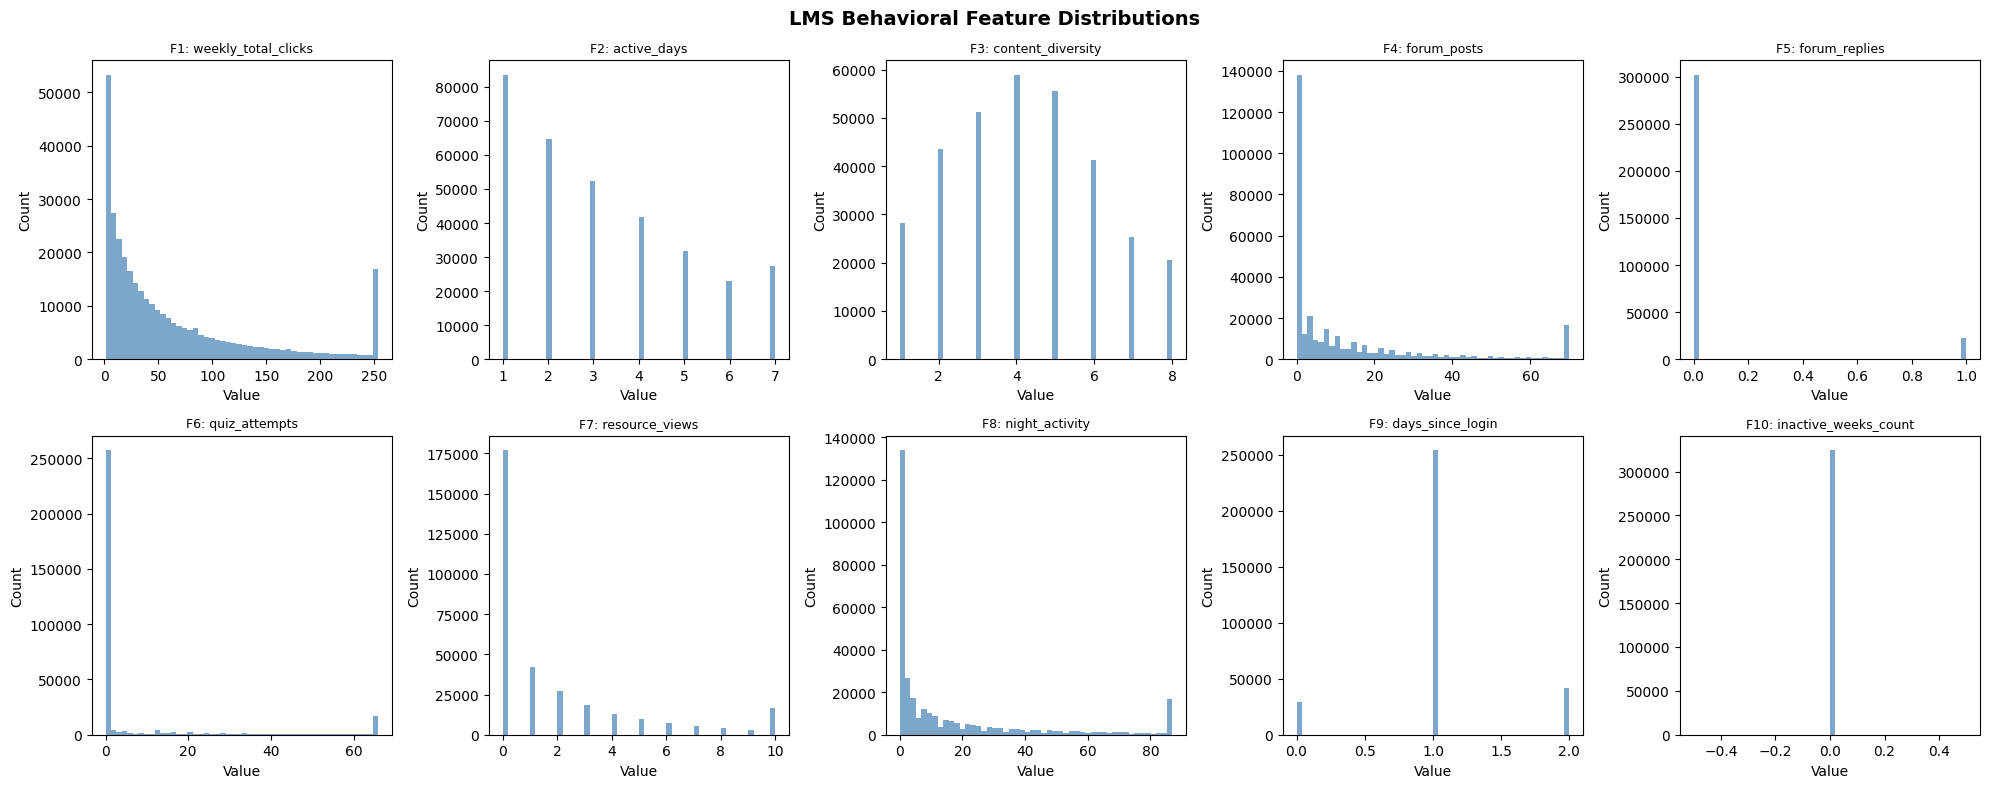

Feature distribution chart saved!


In [9]:
# Visualize feature distributions
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    axes[i].hist(
        features_17[col].clip(upper=features_17[col].quantile(0.95)),
        bins=50,
        color='steelblue',
        alpha=0.7
    )
    axes[i].set_title(f'F{i+1}: {col}', fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('LMS Behavioral Feature Distributions', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/feature_distributions.png')
plt.show()
print("Feature distribution chart saved!")